In [1]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('food_delivery_analytics_cleaned.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  str    
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  float64
 12  w

In [6]:
df.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [11]:
# Drop irrelevant columns (order_id सारखे unique IDs prediction साठी उपयोगी नाहीत)
df = df.drop(["order_id"], axis=1)

# Handle missing values (ratings आणि tip_amount मध्ये काही missing आहेत)
df["delivery_partner_rating"].fillna(df["delivery_partner_rating"].mean(), inplace=True)
df["customer_rating"].fillna(df["customer_rating"].mean(), inplace=True)
df["tip_amount"].fillna(0, inplace=True)  # missing tips = 0 मानलं

C:\Users\hp\AppData\Local\Temp\ipykernel_18968\3244697701.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["delivery_partner_rating"].fillna(df["delivery_partner_rating"].mean(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_18968\3244697701.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

0        19.940541
1        16.101949
2        17.681454
3        11.593912
4        13.272883
           ...    
14995     9.538873
14996    21.562275
14997    19.650710
14998    18.967871
14999    21.512156
Name: tip_amount, Length: 14850, dtype: float64

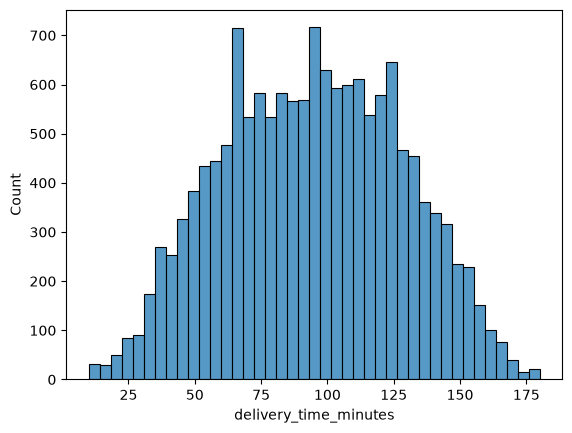

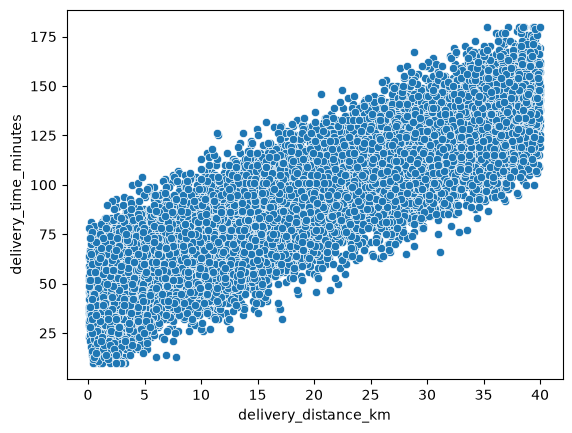

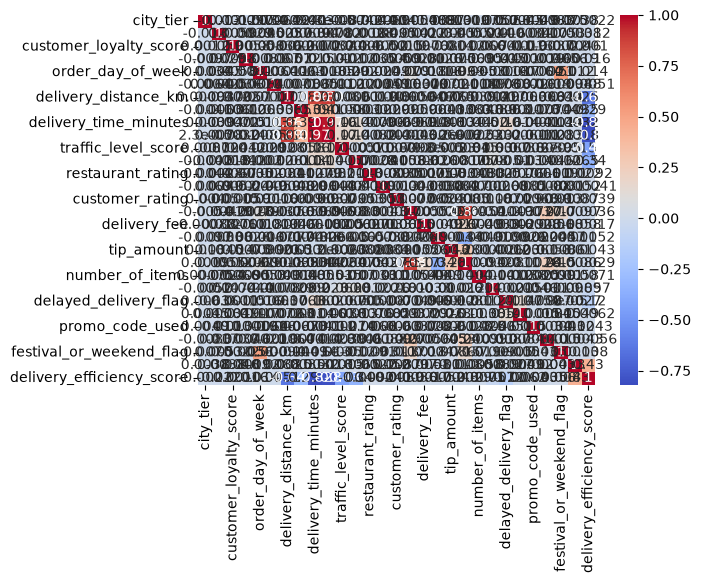

In [12]:
#Step 3: Exploratory Data Analysis (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

# Target variable distribution
sns.histplot(df["delivery_time_minutes"])
plt.show()

# Scatter plot: Distance vs Delivery Time
sns.scatterplot(x=df["delivery_distance_km"], y=df["delivery_time_minutes"])
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()



In [13]:
#Step 4: Feature Engineering
# Peak hour flag (Lunch/Dinner times)
df["peak_hour_flag"] = df["order_hour"].apply(lambda x: 1 if (x in [12,13,19,20]) else 0)

# Weekend flag (Saturday=6, Sunday=7)
df["weekend_flag"] = df["order_day_of_week"].apply(lambda x: 1 if x in [6,7] else 0)

# Interaction feature: Distance * Traffic
df["distance_traffic"] = df["delivery_distance_km"] * df["traffic_level_score"]



In [16]:
#Step 5: Train-Test Split

from sklearn.model_selection import train_test_split

selected_features = [
    "delivery_distance_km",
    "preparation_time_minutes",
    "traffic_level_score",
    "weather_severity_score",
    "restaurant_rating"
]

X = df[selected_features]
y = df["delivery_time_minutes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
#Step 6: Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
from sklearn.metrics import r2_score

# Training झाल्यावर predictions काढा
y_train_pred = rf.predict(X_train_scaled)
y_test_pred = rf.predict(X_test_scaled)

# R² score काढा
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("✅ Training R² Score:", train_r2)
print("✅ Testing R² Score:", test_r2)


✅ Training R² Score: 0.9908674798345972
✅ Testing R² Score: 0.9315518213874455


In [28]:
import pandas as pd

# मोठा dataset load करा
df = pd.read_csv("food_delivery_analytics_cleaned.csv")

# फक्त 1000 rows sample घ्या
df_sample = df.sample(1000)

# छोटा dataset save करा
df_sample.to_csv("food_delivery_analytics_cleaned.csv", index=False)

print("✅ Small dataset saved as food_delivery_small.csv")



✅ Small dataset saved as food_delivery_small.csv


In [27]:
import os
print(os.getcwd())


C:\Users\hp\Project_2


In [29]:
import pickle

In [32]:
import pickle
pickle.dump(rf, open("food_delivery.pkl", "wb"))
